# Predicting antimicrobial resistance in *Neisseria gonorrhoeae* from unitigs

## Reproducible course-project analysis

This notebook repairs and re-evaluates the analysis in `BIF_COMP_PROJECT.ipynb` while preserving that original file unchanged. It asks whether binary genomic unitig profiles can predict resistant (`1`) versus susceptible (`0`) phenotypes for azithromycin, ciprofloxacin, and cefixime.

The notebook is designed to run from top to bottom after **Restart Kernel → Run All**. It uses only files in `DATA/`, writes reproducible outputs to `results/`, and does not install packages or depend on hidden notebook state.

### Scope and interpretation

- Prediction uses **unitigs only**. MIC measurements, resistance labels for other drugs, country, year, and other metadata are not model inputs.
- Exact duplicate unitig profiles are assigned to the same cross-validation fold to reduce train/test leakage.
- Constant-feature removal and univariate feature selection occur inside each training fold.
- Cefixime has only five resistant isolates, so it is audited but excluded from model comparison. Five positives are not enough for a stable five-fold performance estimate.
- The supplied matrices are already labelled `gwas_filtered`. Because the unfiltered unitig matrix and the original GWAS fitting splits are not supplied, upstream selection leakage cannot be ruled out. Results are therefore exploratory and require external validation.


## 1. Environment and paths

The project root is located from the presence of `DATA/metadata.csv`, so the notebook works when launched from the repository root or a subdirectory. Package versions are recorded in the results folder.


In [1]:
from __future__ import annotations

import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline


RANDOM_STATE = 42
N_SPLITS = 5
MIN_POSITIVES_FOR_MODELING = 25  # project rule: at least ~5 positives per test fold
TOP_K_FEATURES = 500


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "DATA" / "metadata.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find DATA/metadata.csv. Start Jupyter from this repository "
        "or one of its subdirectories."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "DATA"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
for directory in (RESULTS_DIR, TABLES_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# A two-second tolerance accommodates filesystem timestamp rounding on Windows.
RUN_STARTED_TIME = time.time() - 2.0
with open(RESULTS_DIR / "run_completion.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "status": "running",
            "message": "This record changes to 'completed' only after all notebook checks pass.",
        },
        handle,
        indent=2,
    )

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

versions = pd.DataFrame(
    {
        "component": ["python", "platform", "numpy", "pandas", "scikit-learn"],
        "version": [
            platform.python_version(),
            platform.platform(),
            np.__version__,
            pd.__version__,
            sklearn.__version__,
        ],
    }
)
versions.to_csv(TABLES_DIR / "environment_versions.csv", index=False)
print(f"Project root: {PROJECT_ROOT}")
display(versions)


Project root: C:\Users\dell\Desktop\BIF PROJECT\N.Gonorrhoeae-AMR-prediction-ML


,component,version
0,python,3.13.15
1,platform,Windows-10-10.0.19045-SP0
2,numpy,2.5.3
3,pandas,3.0.6
4,scikit-learn,1.9.1


## 2. Data inventory and loading

`metadata.csv` contains isolate identifiers, MIC measurements, categorical metadata, and six resistance labels. Only three antibiotics have matching unitig matrices in this repository:

| Antibiotic | Label | Unitig file |
|---|---|---|
| Azithromycin | `azm_sr` | `azm_sr_gwas_filtered_unitigs.Rtab` |
| Ciprofloxacin | `cip_sr` | `cip_sr_gwas_filtered_unitigs.Rtab` |
| Cefixime | `cfx_sr` | `cfx_sr_gwas_filtered_unitigs.Rtab` |

The Rtab files are whitespace-delimited, with unitigs as rows and isolate IDs as columns. The loader transposes each matrix, aligns sample IDs explicitly, drops only samples with a missing label for the antibiotic being analysed, and validates that all genomic values are binary.


In [2]:
ANTIBIOTICS = {
    "Azithromycin": {
        "code": "azm",
        "target": "azm_sr",
        "unitig_file": "azm_sr_gwas_filtered_unitigs.Rtab",
    },
    "Ciprofloxacin": {
        "code": "cip",
        "target": "cip_sr",
        "unitig_file": "cip_sr_gwas_filtered_unitigs.Rtab",
    },
    "Cefixime": {
        "code": "cfx",
        "target": "cfx_sr",
        "unitig_file": "cfx_sr_gwas_filtered_unitigs.Rtab",
    },
}


def load_metadata() -> pd.DataFrame:
    metadata = pd.read_csv(DATA_DIR / "metadata.csv")
    required = {"Sample_ID", *(cfg["target"] for cfg in ANTIBIOTICS.values())}
    missing = required.difference(metadata.columns)
    if missing:
        raise ValueError(f"metadata.csv is missing required columns: {sorted(missing)}")
    if metadata["Sample_ID"].duplicated().any():
        raise ValueError("metadata.csv contains duplicate Sample_ID values.")
    return metadata


def load_antibiotic_data(antibiotic: str, metadata: pd.DataFrame):
    cfg = ANTIBIOTICS[antibiotic]
    path = DATA_DIR / cfg["unitig_file"]
    raw = pd.read_csv(path, sep=r"\s+", index_col=0, low_memory=False)
    raw.index.name = "unitig"

    if raw.index.duplicated().any():
        raise ValueError(f"{path.name} contains duplicate unitig names.")
    if raw.columns.duplicated().any():
        raise ValueError(f"{path.name} contains duplicate isolate columns.")
    if raw.isna().to_numpy().any():
        raise ValueError(f"{path.name} contains missing unitig values.")

    observed = set(np.unique(raw.to_numpy()))
    if not observed.issubset({0, 1}):
        raise ValueError(f"{path.name} is not binary; observed values: {sorted(observed)}")

    labels = (
        metadata.loc[metadata[cfg["target"]].notna(), ["Sample_ID", cfg["target"]]]
        .set_index("Sample_ID")[cfg["target"]]
        .astype("int8")
    )
    label_ids = set(labels.index)
    sample_ids = [sample_id for sample_id in raw.columns if sample_id in label_ids]
    if not sample_ids:
        raise ValueError(f"No sample IDs align for {antibiotic}.")

    X = raw.loc[:, sample_ids].T.astype("uint8", copy=False)
    y = labels.loc[sample_ids]
    if not X.index.equals(y.index):
        raise AssertionError("Feature rows and labels are not in the same order.")
    return X, y, raw.shape


metadata = load_metadata()
print(f"Metadata: {metadata.shape[0]:,} isolates × {metadata.shape[1]:,} columns")
display(pd.DataFrame({"column": metadata.columns, "dtype": metadata.dtypes.astype(str)}))


Metadata: 3,786 isolates × 31 columns


,column,dtype
Sample_ID,Sample_ID,str
Year,Year,float64
Country,Country,str
Continent,Continent,str
Beta.lactamase,Beta.lactamase,str
Azithromycin,Azithromycin,str
Ciprofloxacin,Ciprofloxacin,str
Ceftriaxone,Ceftriaxone,str
Cefixime,Cefixime,str
Tetracycline,Tetracycline,str


## 3. Data-quality audit

The audit reports target missingness, class balance, unitig dimensions, constant unitigs, and duplicated genomic profiles. A duplicated profile means two or more isolate IDs have exactly the same values across all supplied unitigs for that antibiotic. Conflicting-profile groups contain at least one resistant and one susceptible label despite identical supplied features; the filtered representation cannot distinguish those observations.


In [3]:
def profile_groups(X: pd.DataFrame) -> pd.Series:
    # Return a deterministic 64-bit group ID for each complete unitig profile.
    groups = pd.util.hash_pandas_object(X, index=False)
    return pd.Series(groups.to_numpy(), index=X.index, name="profile_group")


data_cache: dict[str, tuple[pd.DataFrame, pd.Series, pd.Series]] = {}
audit_rows = []

for antibiotic, cfg in ANTIBIOTICS.items():
    X, y, raw_shape = load_antibiotic_data(antibiotic, metadata)
    groups = profile_groups(X)
    group_sizes = groups.value_counts()
    duplicate_group_ids = set(group_sizes[group_sizes > 1].index)
    duplicate_rows = int(groups.isin(duplicate_group_ids).sum())
    label_by_group = pd.DataFrame({"group": groups.to_numpy(), "label": y.to_numpy()})
    conflicting_groups = int(label_by_group.groupby("group")["label"].nunique().gt(1).sum())
    constant_unitigs = int(X.min(axis=0).eq(X.max(axis=0)).sum())

    n_resistant = int(y.sum())
    n_susceptible = int((y == 0).sum())
    audit_rows.append(
        {
            "antibiotic": antibiotic,
            "target": cfg["target"],
            "metadata_rows": len(metadata),
            "missing_target": int(metadata[cfg["target"]].isna().sum()),
            "modeling_samples": len(y),
            "susceptible": n_susceptible,
            "resistant": n_resistant,
            "resistant_prevalence": n_resistant / len(y),
            "unitigs": X.shape[1],
            "rtab_unitigs": raw_shape[0],
            "rtab_sample_columns": raw_shape[1],
            "constant_unitigs": constant_unitigs,
            "duplicate_profile_rows": duplicate_rows,
            "duplicate_profile_groups": int((group_sizes > 1).sum()),
            "largest_duplicate_group": int(group_sizes.max()),
            "conflicting_profile_groups": conflicting_groups,
        }
    )
    data_cache[antibiotic] = (X, y, groups)

audit = pd.DataFrame(audit_rows)
audit.to_csv(TABLES_DIR / "data_audit.csv", index=False)
display(audit.style.format({"resistant_prevalence": "{:.2%}"}))


C:\Users\dell\AppData\Local\Temp\ipykernel_1136\2116370070.py:58: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  X = raw.loc[:, sample_ids].T.astype("uint8", copy=False)


C:\Users\dell\AppData\Local\Temp\ipykernel_1136\2116370070.py:58: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  X = raw.loc[:, sample_ids].T.astype("uint8", copy=False)


C:\Users\dell\AppData\Local\Temp\ipykernel_1136\2116370070.py:58: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  X = raw.loc[:, sample_ids].T.astype("uint8", copy=False)


,antibiotic,target,metadata_rows,missing_target,modeling_samples,susceptible,resistant,resistant_prevalence,unitigs,rtab_unitigs,rtab_sample_columns,constant_unitigs,duplicate_profile_rows,duplicate_profile_groups,largest_duplicate_group,conflicting_profile_groups
0,Azithromycin,azm_sr,3786,308,3478,3031,447,12.85%,515,515,3971,25,688,236,17,5
1,Ciprofloxacin,cip_sr,3786,698,3088,1660,1428,46.24%,8873,8873,3971,390,20,10,2,0
2,Cefixime,cfx_sr,3786,385,3401,3396,5,0.15%,384,384,3971,22,1729,416,54,1


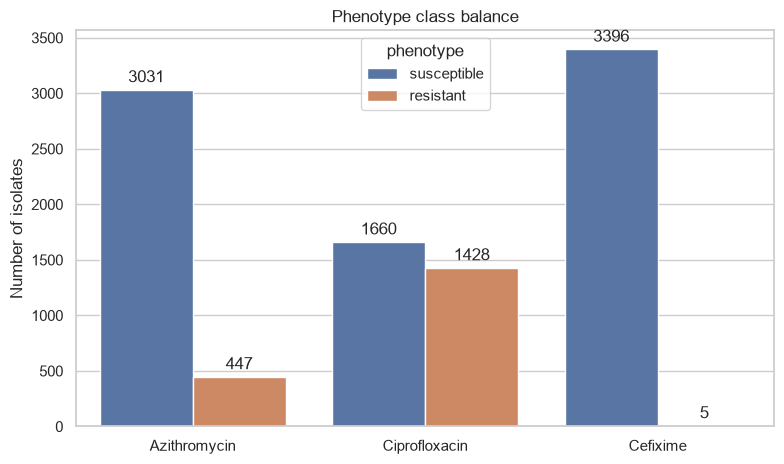

In [4]:
balance_plot = audit.melt(
    id_vars="antibiotic",
    value_vars=["susceptible", "resistant"],
    var_name="phenotype",
    value_name="isolates",
)
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=balance_plot, x="antibiotic", y="isolates", hue="phenotype", ax=ax)
ax.set(title="Phenotype class balance", xlabel="", ylabel="Number of isolates")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "class_balance.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Evaluation design and leakage controls

### Cross-validation

Azithromycin and ciprofloxacin are evaluated with five-fold `StratifiedGroupKFold`. Stratification approximates the class proportion in each fold, while grouping prevents the same unitig profile appearing in both training and test data. Every isolate receives one out-of-fold prediction.

Three prespecified models are compared:

1. **Prevalence baseline** (`DummyClassifier`) to show what is achieved without genomic information.
2. **Class-weighted logistic regression** as a regularised linear genomic baseline.
3. **Class-weighted random forest** as a nonlinear comparison.

For the two learned models, constant-feature removal and chi-squared selection of at most 500 unitigs are fitted inside each training fold. No hyperparameter search is performed; this avoids using the same cross-validation results both to tune and to report performance.

### Metrics

Balanced accuracy, sensitivity, specificity, precision, F1, Matthews correlation coefficient (MCC), ROC AUC, and average precision are reported. Average precision is particularly informative when resistance is uncommon. Confusion counts are retained so a high score cannot obscure missed resistant isolates.

### Why SMOTE is not used

SMOTE would create fractional mixtures of binary unitig profiles that are not observed genomes. Applying it before cross-validation would also leak synthetic information across folds. Class weighting retains real isolates and occurs only during model fitting.

### Remaining upstream limitation

The provided unitig files were already filtered for association with each phenotype. If that filtering used all isolates before this notebook's cross-validation, it leaks outcome information into every fold. The controls below prevent new leakage, but they cannot undo undocumented upstream selection. A stronger study needs the unfiltered unitig matrix (or a fully external validation cohort) and must repeat GWAS/feature filtering separately within training data.


In [5]:
eligibility = audit[["antibiotic", "modeling_samples", "susceptible", "resistant"]].copy()
eligibility["model_comparison"] = eligibility["resistant"] >= MIN_POSITIVES_FOR_MODELING
eligibility["reason"] = np.where(
    eligibility["model_comparison"],
    "Eligible for exploratory 5-fold comparison",
    f"Excluded: fewer than {MIN_POSITIVES_FOR_MODELING} resistant isolates",
)
eligibility.to_csv(TABLES_DIR / "model_eligibility.csv", index=False)
display(eligibility)


,antibiotic,modeling_samples,susceptible,resistant,model_comparison,reason
0,Azithromycin,3478,3031,447,True,Eligible for exploratory 5-fold comparison
1,Ciprofloxacin,3088,1660,1428,True,Eligible for exploratory 5-fold comparison
2,Cefixime,3401,3396,5,False,Excluded: fewer than 25 resistant isolates


In [6]:
def make_models(n_input_features: int) -> dict[str, Pipeline]:
    # At least one constant column is present in AZM/CIP; k remains valid after removal.
    k = min(TOP_K_FEATURES, max(1, n_input_features - 1))
    return {
        "Prevalence baseline": Pipeline(
            [
                ("variance", VarianceThreshold()),
                ("model", DummyClassifier(strategy="prior")),
            ]
        ),
        "Logistic regression": Pipeline(
            [
                ("variance", VarianceThreshold()),
                ("select", SelectKBest(score_func=chi2, k=k)),
                (
                    "model",
                    LogisticRegression(
                        C=1.0,
                        class_weight="balanced",
                        solver="liblinear",
                        max_iter=2_000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "Random forest": Pipeline(
            [
                ("variance", VarianceThreshold()),
                ("select", SelectKBest(score_func=chi2, k=k)),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=150,
                        min_samples_leaf=2,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        n_jobs=-1,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }


def classification_metrics(y_true, y_pred, y_probability) -> dict[str, float | int]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "specificity": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "average_precision": average_precision_score(y_true, y_probability),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def selected_feature_importance(fitted_pipeline: Pipeline, feature_names: pd.Index):
    variance_mask = fitted_pipeline.named_steps["variance"].get_support()
    after_variance = np.asarray(feature_names)[variance_mask]
    selection_mask = fitted_pipeline.named_steps["select"].get_support()
    selected_names = after_variance[selection_mask]
    model = fitted_pipeline.named_steps["model"]
    if hasattr(model, "coef_"):
        values = model.coef_[0]
        kind = "signed_coefficient"
    else:
        values = model.feature_importances_
        kind = "feature_importance"
    return selected_names, values, kind


## 5. Group-aware cross-validated model comparison

The following cell performs all fits. Assertions verify that duplicate-profile groups never cross the train/test boundary and that every test fold contains both classes.


In [7]:
fold_rows = []
fold_class_rows = []
oof_rows = []
importance_rows = []

modeled_antibiotics = eligibility.loc[eligibility["model_comparison"], "antibiotic"].tolist()

for antibiotic in modeled_antibiotics:
    X, y, groups = data_cache[antibiotic]
    models = make_models(X.shape[1])
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    splits = list(cv.split(X, y, groups))

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        train_groups = set(groups.iloc[train_idx])
        test_groups = set(groups.iloc[test_idx])
        if train_groups.intersection(test_groups):
            raise AssertionError("A duplicate-profile group crossed the fold boundary.")
        test_counts = y.iloc[test_idx].value_counts().reindex([0, 1], fill_value=0)
        if (test_counts == 0).any():
            raise AssertionError(f"{antibiotic} fold {fold} is missing a phenotype class.")
        fold_class_rows.append(
            {
                "antibiotic": antibiotic,
                "fold": fold,
                "train_samples": len(train_idx),
                "test_samples": len(test_idx),
                "test_susceptible": int(test_counts.loc[0]),
                "test_resistant": int(test_counts.loc[1]),
            }
        )

    print(f"Evaluating {antibiotic}: {len(y):,} isolates, {X.shape[1]:,} unitigs")
    for model_name, estimator in models.items():
        oof_pred = np.zeros(len(y), dtype="int8")
        oof_probability = np.zeros(len(y), dtype="float64")

        for fold, (train_idx, test_idx) in enumerate(splits, start=1):
            fitted = clone(estimator)
            fitted.fit(X.iloc[train_idx], y.iloc[train_idx])
            fold_pred = fitted.predict(X.iloc[test_idx]).astype("int8")
            fold_probability = fitted.predict_proba(X.iloc[test_idx])[:, 1]
            oof_pred[test_idx] = fold_pred
            oof_probability[test_idx] = fold_probability

            metrics = classification_metrics(y.iloc[test_idx], fold_pred, fold_probability)
            fold_rows.append(
                {"antibiotic": antibiotic, "model": model_name, "fold": fold, **metrics}
            )

            if model_name != "Prevalence baseline":
                names, values, importance_kind = selected_feature_importance(fitted, X.columns)
                for unitig, value in zip(names, values, strict=True):
                    importance_rows.append(
                        {
                            "antibiotic": antibiotic,
                            "model": model_name,
                            "fold": fold,
                            "unitig": unitig,
                            "importance_kind": importance_kind,
                            "importance": float(value),
                            "absolute_importance": float(abs(value)),
                        }
                    )

        overall = classification_metrics(y, oof_pred, oof_probability)
        for sample_id, truth, prediction, probability, group in zip(
            X.index, y, oof_pred, oof_probability, groups, strict=True
        ):
            oof_rows.append(
                {
                    "antibiotic": antibiotic,
                    "model": model_name,
                    "sample_id": sample_id,
                    "profile_group": int(group),
                    "true_label": int(truth),
                    "predicted_label": int(prediction),
                    "resistance_probability": float(probability),
                }
            )
        print(
            f"  {model_name}: balanced accuracy={overall['balanced_accuracy']:.3f}, "
            f"AP={overall['average_precision']:.3f}, sensitivity={overall['sensitivity']:.3f}"
        )

fold_metrics = pd.DataFrame(fold_rows)
fold_classes = pd.DataFrame(fold_class_rows)
oof_predictions = pd.DataFrame(oof_rows)
raw_importance = pd.DataFrame(importance_rows)

fold_metrics.to_csv(TABLES_DIR / "model_metrics_by_fold.csv", index=False)
fold_classes.to_csv(TABLES_DIR / "fold_class_counts.csv", index=False)
oof_predictions.to_csv(TABLES_DIR / "out_of_fold_predictions.csv", index=False)
raw_importance.to_csv(TABLES_DIR / "selected_feature_importance_by_fold.csv", index=False)

display(fold_classes)


Evaluating Azithromycin: 3,478 isolates, 515 unitigs


  Prevalence baseline: balanced accuracy=0.500, AP=0.128, sensitivity=0.000


C:\Users\dell\Desktop\BIF PROJECT\N.Gonorrhoeae-AMR-prediction-ML\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=500 is greater than n_features=479. All the features will be returned.
  warnings.warn(


C:\Users\dell\Desktop\BIF PROJECT\N.Gonorrhoeae-AMR-prediction-ML\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=500 is greater than n_features=474. All the features will be returned.
  warnings.warn(


C:\Users\dell\Desktop\BIF PROJECT\N.Gonorrhoeae-AMR-prediction-ML\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=500 is greater than n_features=477. All the features will be returned.
  warnings.warn(


...

Evaluating Ciprofloxacin: 3,088 isolates, 8,873 unitigs


  Prevalence baseline: balanced accuracy=0.500, AP=0.462, sensitivity=0.000


  Logistic regression: balanced accuracy=0.969, AP=0.985, sensitivity=0.973


  Random forest: balanced accuracy=0.967, AP=0.982, sensitivity=0.973


,antibiotic,fold,train_samples,test_samples,test_susceptible,test_resistant
0,Azithromycin,1,2781,697,607,90
1,Azithromycin,2,2783,695,606,89
2,Azithromycin,3,2783,695,606,89
3,Azithromycin,4,2783,695,606,89
4,Azithromycin,5,2782,696,606,90
5,Ciprofloxacin,1,2471,617,332,285
6,Ciprofloxacin,2,2470,618,332,286
7,Ciprofloxacin,3,2470,618,332,286
8,Ciprofloxacin,4,2471,617,332,285
9,Ciprofloxacin,5,2470,618,332,286


In [8]:
metric_columns = [
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "precision",
    "f1",
    "mcc",
    "roc_auc",
    "average_precision",
]

summary_rows = []
for (antibiotic, model), group in oof_predictions.groupby(["antibiotic", "model"]):
    metrics = classification_metrics(
        group["true_label"], group["predicted_label"], group["resistance_probability"]
    )
    fold_subset = fold_metrics.query("antibiotic == @antibiotic and model == @model")
    row = {"antibiotic": antibiotic, "model": model, **metrics}
    for metric in metric_columns:
        row[f"{metric}_fold_mean"] = fold_subset[metric].mean()
        row[f"{metric}_fold_sd"] = fold_subset[metric].std(ddof=1)
    summary_rows.append(row)

metrics_summary = pd.DataFrame(summary_rows).sort_values(["antibiotic", "average_precision"], ascending=[True, False])
metrics_summary.to_csv(TABLES_DIR / "model_metrics_summary.csv", index=False)
display(
    metrics_summary[
        [
            "antibiotic",
            "model",
            "balanced_accuracy",
            "sensitivity",
            "specificity",
            "precision",
            "f1",
            "mcc",
            "roc_auc",
            "average_precision",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ].style.format({metric: "{:.3f}" for metric in metric_columns})
)


,antibiotic,model,balanced_accuracy,sensitivity,specificity,precision,f1,mcc,roc_auc,average_precision,tn,fp,fn,tp
0,Azithromycin,Logistic regression,0.949,0.926,0.971,0.825,0.872,0.854,0.983,0.919,2943,88,33,414
2,Azithromycin,Random forest,0.915,0.855,0.976,0.840,0.847,0.824,0.978,0.877,2958,73,65,382
1,Azithromycin,Prevalence baseline,0.500,0.000,1.000,0.000,0.000,0.000,0.499,0.128,3031,0,447,0
3,Ciprofloxacin,Logistic regression,0.969,0.973,0.965,0.960,0.966,0.937,0.990,0.985,1602,58,39,1389
5,Ciprofloxacin,Random forest,0.967,0.973,0.961,0.955,0.964,0.933,0.990,0.982,1595,65,38,1390
4,Ciprofloxacin,Prevalence baseline,0.500,0.000,1.000,0.000,0.000,0.000,0.500,0.462,1660,0,1428,0


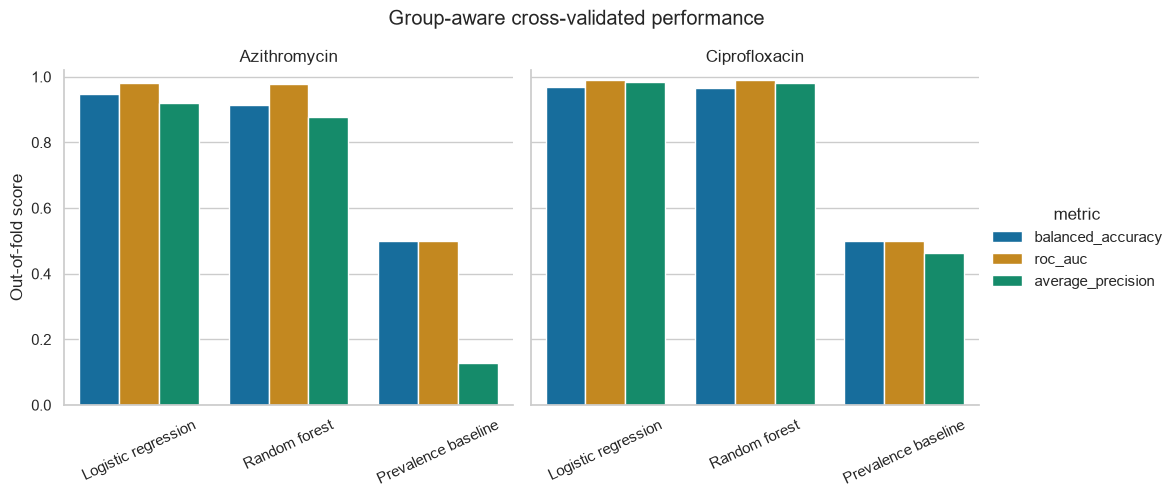

In [9]:
plot_metrics = metrics_summary.melt(
    id_vars=["antibiotic", "model"],
    value_vars=["balanced_accuracy", "roc_auc", "average_precision"],
    var_name="metric",
    value_name="score",
)
g = sns.catplot(
    data=plot_metrics,
    x="model",
    y="score",
    hue="metric",
    col="antibiotic",
    kind="bar",
    height=4.4,
    aspect=1.15,
    palette="colorblind",
)
g.set_axis_labels("", "Out-of-fold score")
g.set_titles("{col_name}")
g.set(ylim=(0, 1.02))
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=25)
g.figure.suptitle("Group-aware cross-validated performance", y=1.05)
g.figure.savefig(FIGURES_DIR / "model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


,antibiotic,model,average_precision
0,Azithromycin,Logistic regression,0.918774
1,Ciprofloxacin,Logistic regression,0.985067


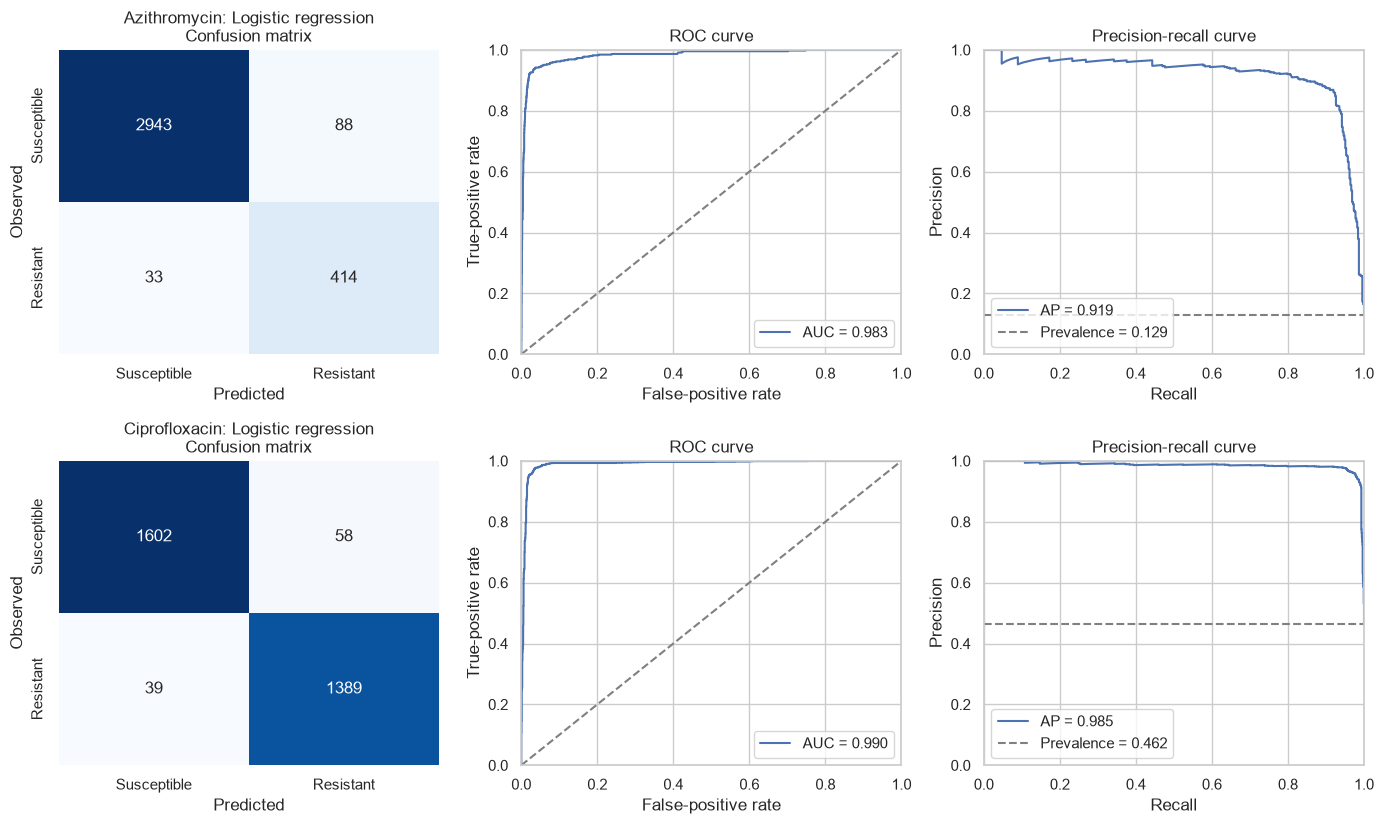

In [10]:
learned = metrics_summary[metrics_summary["model"] != "Prevalence baseline"]
best_models = (
    learned.sort_values(["antibiotic", "average_precision"], ascending=[True, False])
    .groupby("antibiotic", as_index=False)
    .first()[["antibiotic", "model", "average_precision"]]
)
best_models.to_csv(TABLES_DIR / "best_model_by_antibiotic.csv", index=False)
display(best_models)

fig, axes = plt.subplots(len(best_models), 3, figsize=(14, 4.2 * len(best_models)))
if len(best_models) == 1:
    axes = np.asarray([axes])

for row_idx, best in best_models.iterrows():
    subset = oof_predictions.query(
        "antibiotic == @best.antibiotic and model == @best.model"
    )
    y_true = subset["true_label"].to_numpy()
    y_pred = subset["predicted_label"].to_numpy()
    probability = subset["resistance_probability"].to_numpy()

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Susceptible", "Resistant"],
        yticklabels=["Susceptible", "Resistant"],
        ax=axes[row_idx, 0],
    )
    axes[row_idx, 0].set(
        title=f"{best.antibiotic}: {best.model}\nConfusion matrix",
        xlabel="Predicted",
        ylabel="Observed",
    )

    fpr, tpr, _ = roc_curve(y_true, probability)
    roc_auc = roc_auc_score(y_true, probability)
    axes[row_idx, 1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[row_idx, 1].plot([0, 1], [0, 1], "--", color="grey")
    axes[row_idx, 1].set(
        title="ROC curve", xlabel="False-positive rate", ylabel="True-positive rate", xlim=(0, 1), ylim=(0, 1)
    )
    axes[row_idx, 1].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, probability)
    ap = average_precision_score(y_true, probability)
    prevalence = y_true.mean()
    axes[row_idx, 2].plot(recall, precision, label=f"AP = {ap:.3f}")
    axes[row_idx, 2].axhline(prevalence, linestyle="--", color="grey", label=f"Prevalence = {prevalence:.3f}")
    axes[row_idx, 2].set(
        title="Precision-recall curve", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1)
    )
    axes[row_idx, 2].legend(loc="lower left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_model_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Uncertainty and sampling-context stress tests

A single score can conceal sampling variability. The table below therefore uses a **profile-group bootstrap**: complete duplicate unitig profiles are resampled as clusters, rather than treating correlated rows as independent. The intervals quantify uncertainty conditional on this dataset and pipeline; they do not repair the upstream GWAS-filtering limitation.

Performance is also stratified by continent when a subgroup has at least 100 labelled isolates and at least 25 observations in each class. These are descriptive slices of the same out-of-fold predictions—not geographic holdout validation—and are included to reveal heterogeneity rather than imply transportability.


In [11]:
def profile_group_bootstrap_interval(
    frame: pd.DataFrame,
    metric: str,
    *,
    n_resamples: int = 500,
    seed: int = RANDOM_STATE,
) -> tuple[float, float, int]:
    '''Return a percentile interval after resampling complete unitig-profile groups.'''
    frame = frame.reset_index(drop=True)
    group_positions = frame.groupby("profile_group", sort=False).indices
    group_ids = np.asarray(list(group_positions))
    rng = np.random.default_rng(seed)
    values = []

    for _ in range(n_resamples):
        sampled_groups = rng.choice(group_ids, size=len(group_ids), replace=True)
        sampled_positions = np.concatenate([group_positions[group] for group in sampled_groups])
        sample = frame.iloc[sampled_positions]
        if sample["true_label"].nunique() < 2:
            continue
        if metric == "balanced_accuracy":
            value = balanced_accuracy_score(sample["true_label"], sample["predicted_label"])
        elif metric == "roc_auc":
            value = roc_auc_score(sample["true_label"], sample["resistance_probability"])
        elif metric == "average_precision":
            value = average_precision_score(sample["true_label"], sample["resistance_probability"])
        else:
            raise ValueError(f"Unsupported bootstrap metric: {metric}")
        values.append(value)

    if len(values) < 0.95 * n_resamples:
        raise AssertionError(f"Too few valid bootstrap samples for {metric}: {len(values)}")
    lower, upper = np.quantile(values, [0.025, 0.975])
    return float(lower), float(upper), len(values)


bootstrap_rows = []
bootstrap_metrics = ["balanced_accuracy", "roc_auc", "average_precision"]
for best_idx, best in best_models.reset_index(drop=True).iterrows():
    subset = oof_predictions.query(
        "antibiotic == @best.antibiotic and model == @best.model"
    ).copy()
    point_metrics = classification_metrics(
        subset["true_label"], subset["predicted_label"], subset["resistance_probability"]
    )
    for metric_idx, metric in enumerate(bootstrap_metrics):
        lower, upper, valid_resamples = profile_group_bootstrap_interval(
            subset,
            metric,
            seed=RANDOM_STATE + 100 * best_idx + metric_idx,
        )
        bootstrap_rows.append(
            {
                "antibiotic": best.antibiotic,
                "model": best.model,
                "metric": metric,
                "estimate": point_metrics[metric],
                "ci_2.5%": lower,
                "ci_97.5%": upper,
                "valid_resamples": valid_resamples,
                "profile_groups": subset["profile_group"].nunique(),
            }
        )

bootstrap_intervals = pd.DataFrame(bootstrap_rows)
bootstrap_intervals.to_csv(TABLES_DIR / "bootstrap_confidence_intervals.csv", index=False)
display(bootstrap_intervals.style.format({"estimate": "{:.3f}", "ci_2.5%": "{:.3f}", "ci_97.5%": "{:.3f}"}))


,antibiotic,model,metric,estimate,ci_2.5%,ci_97.5%,valid_resamples,profile_groups
0,Azithromycin,Logistic regression,balanced_accuracy,0.949,0.936,0.962,500,3026
1,Azithromycin,Logistic regression,roc_auc,0.983,0.975,0.989,500,3026
2,Azithromycin,Logistic regression,average_precision,0.919,0.888,0.945,500,3026
3,Ciprofloxacin,Logistic regression,balanced_accuracy,0.969,0.963,0.975,500,3078
4,Ciprofloxacin,Logistic regression,roc_auc,0.990,0.986,0.993,500,3078
5,Ciprofloxacin,Logistic regression,average_precision,0.985,0.979,0.990,500,3078


,antibiotic,model,continent,samples,susceptible,resistant,resistant_prevalence,eligible_for_metrics,balanced_accuracy,sensitivity,specificity,precision,f1,mcc,roc_auc,average_precision,tn,fp,fn,tp
0,Azithromycin,Logistic regression,Africa,44,44,0,0.000000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Azithromycin,Logistic regression,America,1503,1247,256,0.170326,True,0.917594,0.894531,0.940658,0.755776,0.819320,0.782575,0.967500,0.877033,1173.0,74.0,27.0,229.0
2,Azithromycin,Logistic regression,Asia,150,148,2,0.013333,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Azithromycin,Logistic regression,Europe,1369,1182,187,0.136596,True,0.983383,0.978610,0.988156,0.928934,0.953125,0.945918,0.993933,0.966430,1168.0,14.0,4.0,183.0
4,Azithromycin,Logistic regression,Oceania,411,409,2,0.004866,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Ciprofloxacin,Logistic regression,Africa,44,42,2,0.045455,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Ciprofloxacin,Logistic regression,America,1297,600,697,0.537394,True,0.985210,0.987088,0.983333,0.985673,0.986380,0.970535,0.996836,0.997938,590.0,10.0,9.0,688.0
7,Ciprofloxacin,Logistic regression,Asia,150,79,71,0.473333,True,0.852915,0.845070,0.860759,0.845070,0.845070,0.705830,0.919772,0.906615,68.0,11.0,11.0,60.0
8,Ciprofloxacin,Logistic regression,Europe,1185,654,531,0.448101,True,0.965411,0.973635,0.957187,0.948624,0.960967,0.928783,0.985229,0.972467,626.0,28.0,14.0,517.0
9,Ciprofloxacin,Logistic regression,Oceania,411,284,127,0.309002,True,0.964470,0.960630,0.968310,0.931298,0.945736,0.921158,0.982173,0.971665,275.0,9.0,5.0,122.0


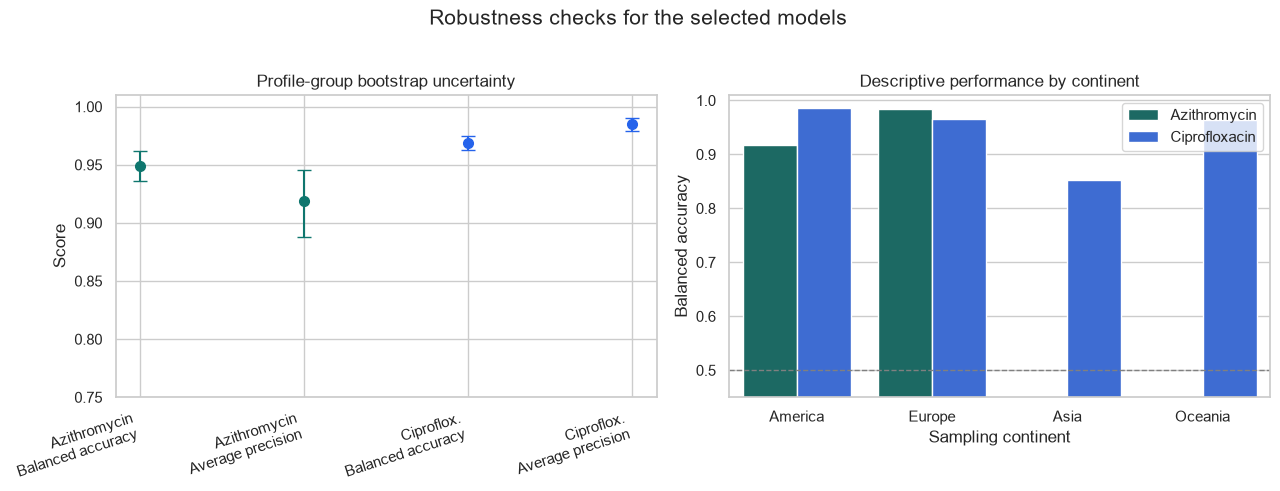

In [12]:
metadata_context = metadata[["Sample_ID", "Continent", "Country", "Year"]].rename(
    columns={"Sample_ID": "sample_id"}
)
context_rows = []

for _, best in best_models.iterrows():
    selected_oof = oof_predictions.query(
        "antibiotic == @best.antibiotic and model == @best.model"
    ).merge(metadata_context, on="sample_id", how="left", validate="one_to_one")

    for continent, subset in selected_oof.dropna(subset=["Continent"]).groupby("Continent"):
        class_counts = subset["true_label"].value_counts().reindex([0, 1], fill_value=0)
        eligible = len(subset) >= 100 and class_counts.min() >= 25
        row = {
            "antibiotic": best.antibiotic,
            "model": best.model,
            "continent": continent,
            "samples": len(subset),
            "susceptible": int(class_counts.loc[0]),
            "resistant": int(class_counts.loc[1]),
            "resistant_prevalence": float(subset["true_label"].mean()),
            "eligible_for_metrics": eligible,
        }
        if eligible:
            row.update(
                classification_metrics(
                    subset["true_label"],
                    subset["predicted_label"],
                    subset["resistance_probability"],
                )
            )
        context_rows.append(row)

context_performance = pd.DataFrame(context_rows).sort_values(["antibiotic", "continent"])
context_performance.to_csv(TABLES_DIR / "subgroup_performance_by_continent.csv", index=False)
display(context_performance)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

interval_plot = bootstrap_intervals.query(
    "metric in ['balanced_accuracy', 'average_precision']"
).copy()
interval_plot["label"] = (
    interval_plot["antibiotic"].str.replace("floxacin", "flox.")
    + "\n"
    + interval_plot["metric"].map(
        {"balanced_accuracy": "Balanced accuracy", "average_precision": "Average precision"}
    )
)
colors = {"Azithromycin": "#0F766E", "Ciprofloxacin": "#2563EB"}
for position, (_, row) in enumerate(interval_plot.iterrows()):
    axes[0].errorbar(
        position,
        row["estimate"],
        yerr=[[row["estimate"] - row["ci_2.5%"]], [row["ci_97.5%"] - row["estimate"]]],
        fmt="o",
        color=colors[row["antibiotic"]],
        capsize=5,
        markersize=7,
    )
axes[0].set_xticks(range(len(interval_plot)), interval_plot["label"], rotation=18, ha="right")
axes[0].set(title="Profile-group bootstrap uncertainty", ylabel="Score", ylim=(0.75, 1.01))

eligible_context = context_performance.loc[context_performance["eligible_for_metrics"]].copy()
sns.barplot(
    data=eligible_context,
    x="continent",
    y="balanced_accuracy",
    hue="antibiotic",
    palette=colors,
    ax=axes[1],
)
axes[1].axhline(0.5, linestyle="--", color="grey", linewidth=1)
axes[1].set(
    title="Descriptive performance by continent",
    xlabel="Sampling continent",
    ylabel="Balanced accuracy",
    ylim=(0.45, 1.01),
)
axes[1].legend(title="")

fig.suptitle("Robustness checks for the selected models", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "robustness_summary.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Predictive unitig associations

Feature importance is aggregated across the five fitted folds. `selection_fraction` is the fraction of folds in which a unitig passed the in-fold chi-squared selector. `stability_weighted_importance` downweights high importance seen in only a few folds. For logistic regression, the sign indicates association with the model's resistant (positive) or susceptible (negative) prediction; it does **not** demonstrate causality.

The table also reports the observed prevalence of each selected unitig in resistant and susceptible isolates. These are descriptive, full-dataset summaries and are not additional validation.


In [13]:
importance_summary = (
    raw_importance.groupby(["antibiotic", "model", "unitig", "importance_kind"], as_index=False)
    .agg(
        selected_folds=("fold", "nunique"),
        mean_importance=("importance", "mean"),
        mean_absolute_importance=("absolute_importance", "mean"),
        importance_sd=("importance", "std"),
    )
)
importance_summary["selection_fraction"] = importance_summary["selected_folds"] / N_SPLITS
importance_summary["stability_weighted_importance"] = (
    importance_summary["selection_fraction"] * importance_summary["mean_absolute_importance"]
)

prevalence_rows = []
for antibiotic in modeled_antibiotics:
    X, y, _ = data_cache[antibiotic]
    for unitig in importance_summary.loc[importance_summary["antibiotic"] == antibiotic, "unitig"].unique():
        prevalence_rows.append(
            {
                "antibiotic": antibiotic,
                "unitig": unitig,
                "prevalence_susceptible": float(X.loc[y == 0, unitig].mean()),
                "prevalence_resistant": float(X.loc[y == 1, unitig].mean()),
            }
        )

importance_summary = importance_summary.merge(
    pd.DataFrame(prevalence_rows), on=["antibiotic", "unitig"], how="left"
)
importance_summary["prevalence_difference_R_minus_S"] = (
    importance_summary["prevalence_resistant"] - importance_summary["prevalence_susceptible"]
)
importance_summary = importance_summary.sort_values(
    ["antibiotic", "model", "stability_weighted_importance"], ascending=[True, True, False]
)
importance_summary.to_csv(TABLES_DIR / "unitig_importance_stability.csv", index=False)

top_unitigs = importance_summary.groupby(["antibiotic", "model"], as_index=False).head(20)
top_unitigs.to_csv(TABLES_DIR / "top_predictive_unitigs.csv", index=False)
display(top_unitigs)


,antibiotic,model,unitig,importance_kind,selected_folds,mean_importance,mean_absolute_importance,importance_sd,selection_fraction,stability_weighted_importance,prevalence_susceptible,prevalence_resistant,prevalence_difference_R_minus_S
372,Azithromycin,Logistic regression,GGGTTTAAAACGTCGTGAGACAGTTTGGTCCCTATCTGCAGTGGGC...,signed_coefficient,5,6.432968,6.432968,0.185436,1.0,6.432968,0.020455,0.713647,0.693191
427,Azithromycin,Logistic regression,TCATCTCGTATGCCGTCTTCTGCTTGAAAAA,signed_coefficient,5,-2.454219,2.454219,0.194104,1.0,2.454219,0.995711,0.756152,-0.239559
375,Azithromycin,Logistic regression,GGTCAGTTCGAAAAGGATGGTATTTTGTTGACCGCCG,signed_coefficient,5,2.081327,2.081327,0.277307,1.0,2.081327,0.994721,0.982103,-0.012618
78,Azithromycin,Logistic regression,ACCGTAACCGGCAATGCGGATATTACGGTCA,signed_coefficient,5,-1.988839,1.988839,0.158951,1.0,1.988839,0.948532,0.689038,-0.259494
422,Azithromycin,Logistic regression,TATCCTTCCATTTTAGTGCCTTCGCCGTATCT,signed_coefficient,5,-1.690169,1.690169,0.275910,1.0,1.690169,0.088090,0.060403,-0.027687
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,Ciprofloxacin,Random forest,CCGAAGTAGATGCTGAAACCGTTGAAAAAGAACGCCA,feature_importance,5,0.012391,0.012391,0.002359,1.0,0.012391,0.350602,0.959384,0.608781
1860,Ciprofloxacin,Random forest,CTTGGGCAATACGACGTTTTTGACCGCGATGCTTCAGGA,feature_importance,5,0.012384,0.012384,0.004674,1.0,0.012384,0.062651,0.716387,0.653736
1964,Ciprofloxacin,Random forest,GCTTACGAACCGTCCGGCAGCGGAAGCGGGCG,feature_importance,5,0.011829,0.011829,0.005060,1.0,0.011829,0.729518,0.107143,-0.622375
1909,Ciprofloxacin,Random forest,GCAAATTTACGACGAACCCGAATTCGATCCTCAAGAGCTGCAAT,feature_importance,5,0.011521,0.011521,0.004192,1.0,0.011521,0.084940,0.445378,0.360438


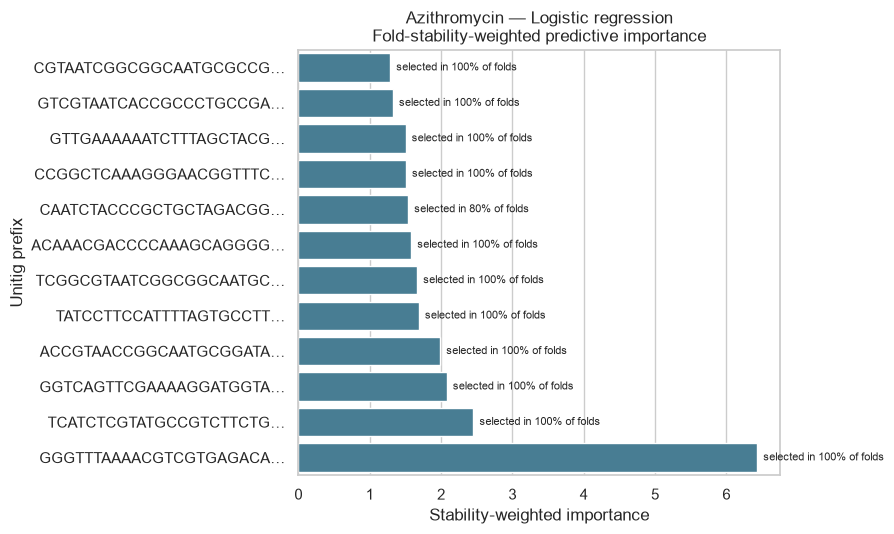

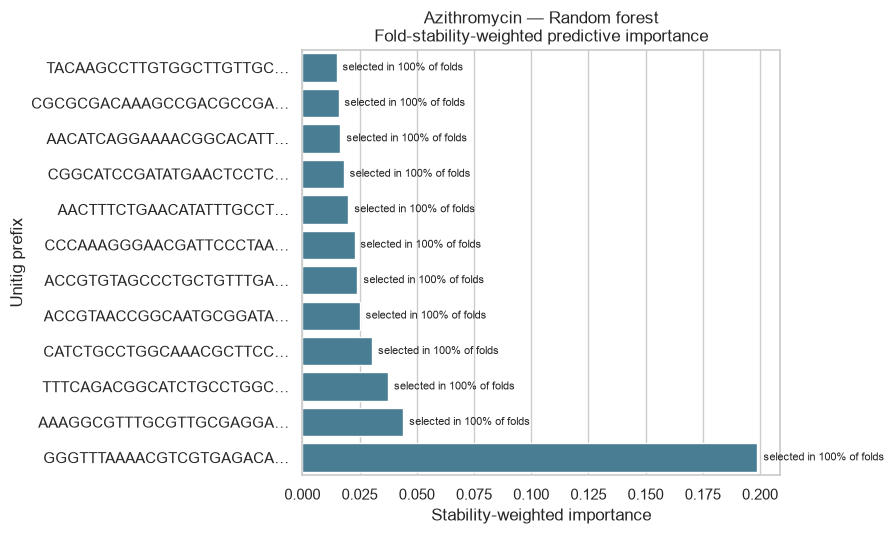

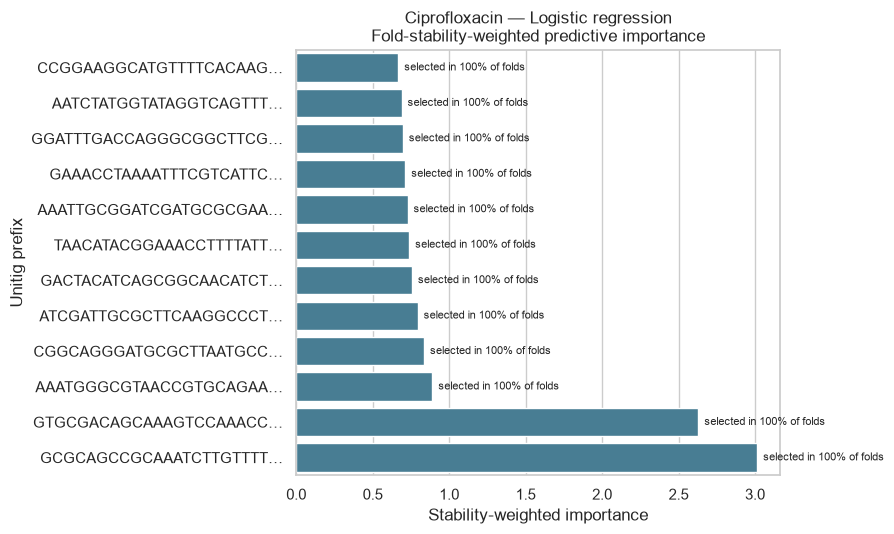

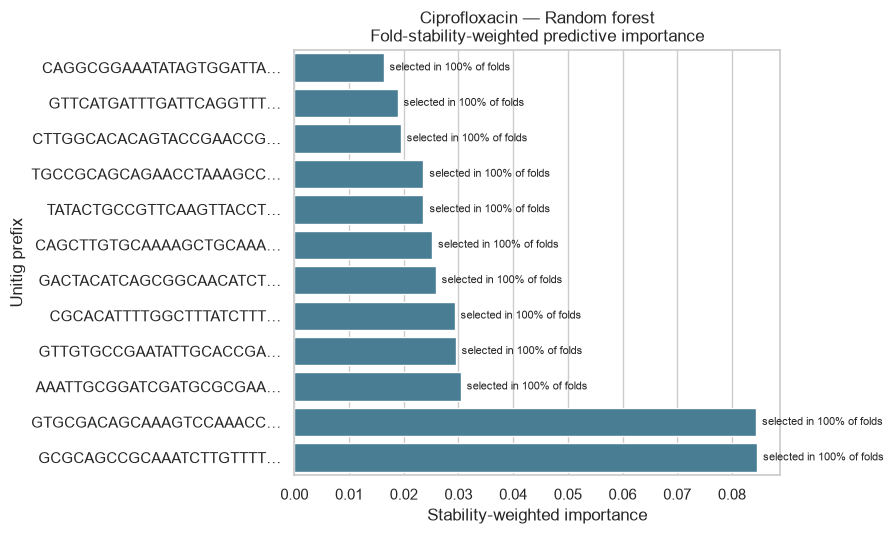

In [14]:
plot_data = top_unitigs.copy()
plot_data["short_unitig"] = plot_data["unitig"].str.slice(0, 22) + "…"

for (antibiotic, model), subset in plot_data.groupby(["antibiotic", "model"]):
    subset = subset.nlargest(12, "stability_weighted_importance").sort_values("stability_weighted_importance")
    fig, ax = plt.subplots(figsize=(9, 5.5))
    bars = sns.barplot(
        data=subset,
        x="stability_weighted_importance",
        y="short_unitig",
        color="#3B82A0",
        ax=ax,
    )
    for patch, fraction in zip(bars.patches, subset["selection_fraction"], strict=True):
        ax.text(
            patch.get_width(),
            patch.get_y() + patch.get_height() / 2,
            f"  selected in {fraction:.0%} of folds",
            va="center",
            fontsize=8,
        )
    ax.set(
        title=f"{antibiotic} — {model}\nFold-stability-weighted predictive importance",
        xlabel="Stability-weighted importance",
        ylabel="Unitig prefix",
    )
    fig.tight_layout()
    filename = f"top_unitigs_{ANTIBIOTICS[antibiotic]['code']}_{model.lower().replace(' ', '_')}.png"
    fig.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()


## 8. Biological interpretation boundaries

This project identifies **predictive associations**, not validated resistance mechanisms. No BLAST alignment, reference-genome mapping, gene annotation, or experimental validation is supplied in the repository, so the unitigs above are intentionally left unlabelled.

Known loci such as *gyrA* and *parC* can be relevant to fluoroquinolone resistance, while *penA* and other loci can be relevant to cephalosporin susceptibility. That background does not establish that any unitig in this notebook maps to those genes. A defensible follow-up would save exact unitig sequences, align them against a documented *N. gonorrhoeae* reference, report coordinates, strand, alignment identity and coverage, account for population structure, and test the association in an independent collection.

The models are not clinical decision-support tools. Their inputs were prefiltered for association, their evaluation is internal, and no temporal, geographic, lineage-aware, or external validation was available.


## 9. Reproduced result summary and run checks

This final cell writes a machine-readable completion record only after all previous cells have executed and all expected tables and figures exist.


In [15]:
expected_outputs = [
    TABLES_DIR / "environment_versions.csv",
    TABLES_DIR / "data_audit.csv",
    TABLES_DIR / "model_eligibility.csv",
    TABLES_DIR / "fold_class_counts.csv",
    TABLES_DIR / "model_metrics_by_fold.csv",
    TABLES_DIR / "model_metrics_summary.csv",
    TABLES_DIR / "out_of_fold_predictions.csv",
    TABLES_DIR / "selected_feature_importance_by_fold.csv",
    TABLES_DIR / "unitig_importance_stability.csv",
    TABLES_DIR / "top_predictive_unitigs.csv",
    TABLES_DIR / "best_model_by_antibiotic.csv",
    TABLES_DIR / "bootstrap_confidence_intervals.csv",
    TABLES_DIR / "subgroup_performance_by_continent.csv",
    FIGURES_DIR / "class_balance.png",
    FIGURES_DIR / "model_comparison.png",
    FIGURES_DIR / "best_model_diagnostics.png",
    FIGURES_DIR / "robustness_summary.png",
]
missing_outputs = [str(path.relative_to(PROJECT_ROOT)) for path in expected_outputs if not path.is_file()]
if missing_outputs:
    raise AssertionError(f"Expected outputs were not created: {missing_outputs}")

stale_outputs = [
    str(path.relative_to(PROJECT_ROOT))
    for path in expected_outputs
    if path.stat().st_mtime < RUN_STARTED_TIME
]
if stale_outputs:
    raise AssertionError(f"Expected outputs were not refreshed by this run: {stale_outputs}")

if metrics_summary[metric_columns].isna().any().any():
    raise AssertionError("The model summary contains missing metric values.")

best_reproduced = metrics_summary.merge(best_models[["antibiotic", "model"]], on=["antibiotic", "model"])
display(
    best_reproduced[
        ["antibiotic", "model", "balanced_accuracy", "sensitivity", "specificity", "roc_auc", "average_precision"]
    ].style.format({metric: "{:.3f}" for metric in metric_columns})
)

completion_record = {
    "status": "completed",
    "random_state": RANDOM_STATE,
    "cross_validation": "5-fold StratifiedGroupKFold grouped by complete unitig profile",
    "modeled_antibiotics": modeled_antibiotics,
    "descriptive_only": eligibility.loc[~eligibility["model_comparison"], "antibiotic"].tolist(),
    "upstream_limitation": (
        "Input matrices were already GWAS-filtered; upstream feature-selection leakage cannot be excluded."
    ),
    "expected_output_count": len(expected_outputs),
}
with open(RESULTS_DIR / "run_completion.json", "w", encoding="utf-8") as handle:
    json.dump(completion_record, handle, indent=2)

print("Notebook checks passed. All expected result files were created.")
print(json.dumps(completion_record, indent=2))


,antibiotic,model,balanced_accuracy,sensitivity,specificity,roc_auc,average_precision
0,Azithromycin,Logistic regression,0.949,0.926,0.971,0.983,0.919
1,Ciprofloxacin,Logistic regression,0.969,0.973,0.965,0.990,0.985


Notebook checks passed. All expected result files were created.
{
  "status": "completed",
  "random_state": 42,
  "cross_validation": "5-fold StratifiedGroupKFold grouped by complete unitig profile",
  "modeled_antibiotics": [
    "Azithromycin",
    "Ciprofloxacin"
  ],
  "descriptive_only": [
    "Cefixime"
  ],
  "upstream_limitation": "Input matrices were already GWAS-filtered; upstream feature-selection leakage cannot be excluded.",
  "expected_output_count": 17
}


## 10. Conclusions

- The local repository contains complete binary unitig matrices and phenotype labels for azithromycin, ciprofloxacin, and cefixime.
- Azithromycin and ciprofloxacin support an exploratory, group-aware cross-validated comparison. The exact reproduced scores are shown above and saved in `results/tables/model_metrics_summary.csv`.
- Cefixime has 3,396 susceptible and only 5 resistant isolates; it is not presented as a model-performance result.
- Duplicate and conflicting unitig profiles demonstrate why simple random train/test splitting can be optimistic and why the filtered feature representation is not sufficient to distinguish every phenotype.
- The important unitigs are model-associated predictors only. No gene mapping or mechanism is claimed.
- The largest unresolved limitation is that the supplied unitigs were already GWAS-filtered before cross-validation. External validation or the unfiltered unitig matrix is required before making generalisation or clinical claims.
